In [28]:
import sys, os, glob, torch
import matplotlib.pyplot as plt

sys.path.append(os.getcwd())         
sys.path.append(os.path.join(os.getcwd(), "configs"))

from unet import UNet
from diffusion import GaussianDiffusion
from data import unnormalize

print("CUDA:", torch.cuda.is_available(), torch.cuda.get_device_name(0))

CUDA: True NVIDIA L4


In [29]:
from config_exp1 import config  
# switches:   
#          from config_exp2_t250 import config 
#          from config_exp2_cosine import config 
#          from config_exp3 import config 

print("Running demo for:", config.run_name, "| T =", config.T, "| schedule =", config.schedule)

Running demo for: exp1_baseline_full | T = 1000 | schedule = linear


In [30]:
model = UNet(
    image_size=config.image_size,
    image_channels=config.image_channels,
    base_channels=config.base_channels,
    channel_mult=config.channel_mult,
    num_res_blocks=config.num_res_blocks,
    attn_resolutions=config.attn_resolutions,
    dropout=config.dropout,
).cuda()

diffusion = GaussianDiffusion(
    timesteps=config.T,
    beta_start=config.beta_start,
    beta_end=config.beta_end,
    schedule=config.schedule,
    device="cuda",
)

In [31]:
ckpt_dir = f"runs/{config.run_name}/checkpoints"
raw_ckpts = sorted(
    [p for p in glob.glob(f"{ckpt_dir}/step_*.pt") if "_ema" not in p],
    key=lambda p: int(p.split("step_")[1].split(".pt")[0])
)
first_ckpt, last_ckpt = raw_ckpts[0], raw_ckpts[-1]
first_step = first_ckpt.split("step_")[1].split(".pt")[0]
last_step = last_ckpt.split("step_")[1].split(".pt")[0]
print(f"First checkpoint: step {first_step}")
print(f"Last checkpoint: step {last_step}")

First checkpoint: step 500
Last checkpoint: step 12000


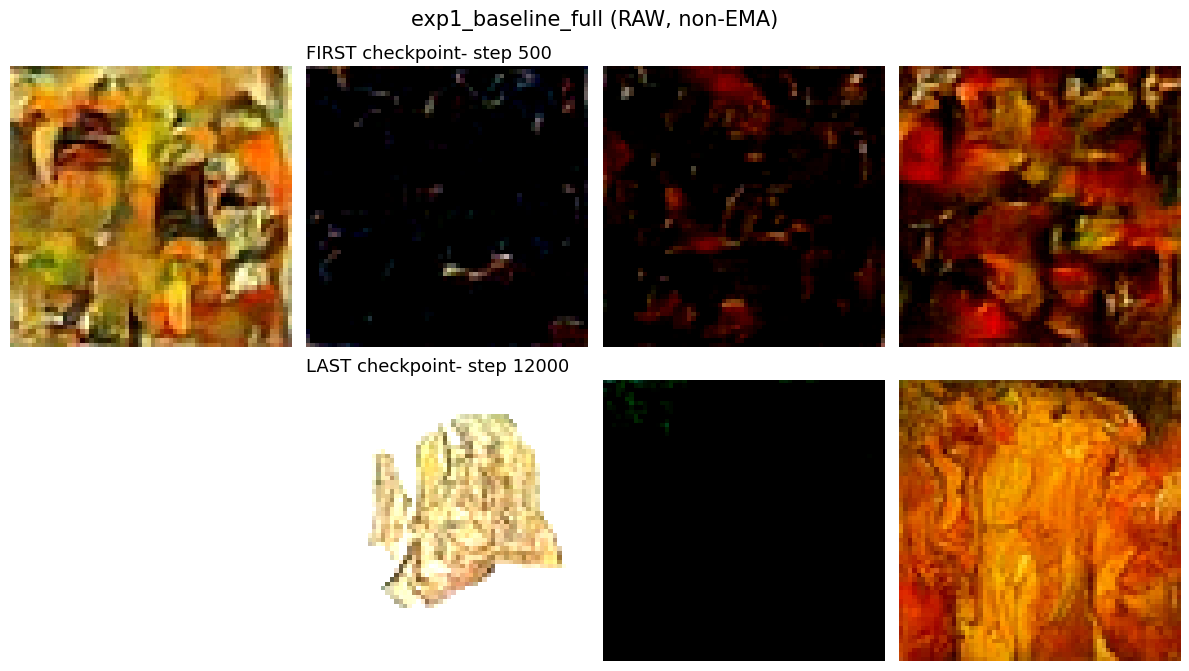

In [34]:
def sample_from_checkpoint(ckpt_path):
    model.load_state_dict(torch.load(ckpt_path, map_location="cuda"))
    model.eval()
    with torch.no_grad():
        samples = diffusion.sample(model, batch_size=4, image_size=config.image_size)
    return unnormalize(samples).clamp(0, 1)

first_samples = sample_from_checkpoint(first_ckpt)
last_samples = sample_from_checkpoint(last_ckpt)

fig, axes = plt.subplots(2, 4, figsize=(12, 7))
for i in range(4):
    axes[0, i].imshow(first_samples[i].permute(1, 2, 0).cpu().numpy())
    axes[0, i].axis("off")
    axes[1, i].imshow(last_samples[i].permute(1, 2, 0).cpu().numpy())
    axes[1, i].axis("off")

axes[0, 1].set_title(f"FIRST checkpoint- step {first_step}", fontsize=13, loc="left")
axes[1, 1].set_title(f"LAST checkpoint- step {last_step}", fontsize=13, loc="left")

plt.suptitle(f"{config.run_name} (RAW, non-EMA)", fontsize=15)
plt.tight_layout()
plt.show()